## Recommendation System using Python

In [18]:
import pandas as pd
import numpy as np

In [19]:
column_names = ['user_id','item_id','rating','timestamp']
df = pd.read_csv('u.data.txt', sep = '\t', names=column_names)

In [20]:
df.head()

,user_id,item_id,rating,timestamp
0,0,50,5,881250949
1,0,172,5,881250949
2,0,133,1,881250949
3,196,242,3,881250949
4,186,302,3,891717742


#### Now let's get the movie titles

In [21]:
movie_title = pd.read_csv('Movie_Id_Titles.txt')
movie_title.head()

,item_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [22]:
df = df.merge(movie_title,on = 'item_id')

In [23]:
df.head(10)

,user_id,item_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)
5,22,377,1,878887116,Heavyweights (1994)
6,244,51,2,880606923,Legends of the Fall (1994)
7,166,346,1,886397596,Jackie Brown (1997)
8,298,474,4,884182806,Dr. Strangelove or: How I Learned to Stop Worr...
9,115,265,2,881171488,"Hunt for Red October, The (1990)"


 ## Explorotory Data Analysis

### visualization Imports

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('white')
%matplotlib inline

#### Let's create a ratings dataframe with average rating and number of ratings

In [25]:
df.groupby('title')['rating'].mean().sort_values(ascending = False).head()

title
Aiqing wansui (1994)                                 5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
They Made Me a Criminal (1939)                       5.0
Name: rating, dtype: float64

In [26]:
df.groupby('title')['rating'].count().sort_values(ascending = False).head()

title
Star Wars (1977)             584
Contact (1997)               509
Fargo (1996)                 508
Return of the Jedi (1983)    507
Liar Liar (1997)             485
Name: rating, dtype: int64

In [27]:
ratings = pd.DataFrame(df.groupby('title')['rating'].mean())
ratings.head()

,rating
title,
'Til There Was You (1997),2.333333
1-900 (1994),2.600000
101 Dalmatians (1996),2.908257
12 Angry Men (1957),4.344000
187 (1997),3.024390


In [28]:
ratings['No.of.Ratings'] = pd.DataFrame(df.groupby('title')['rating'].count())

ratings.head()

,rating,No.of.Ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


<Axes: >

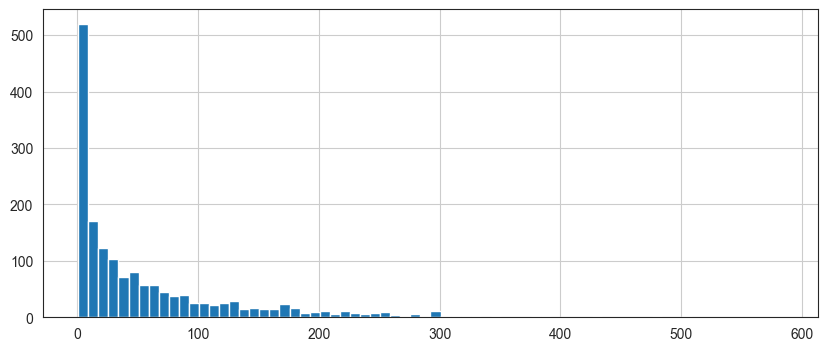

In [29]:
plt.figure(figsize=(10,4))
ratings['No.of.Ratings'].hist(bins = 70)

<Axes: >

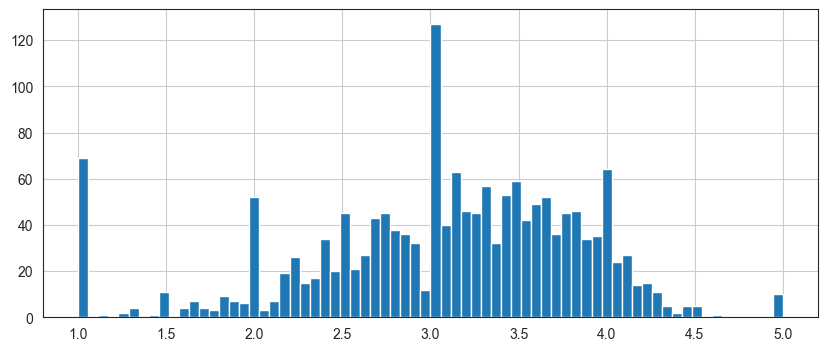

In [30]:
plt.figure(figsize=(10,4))
ratings['rating'].hist(bins = 70)

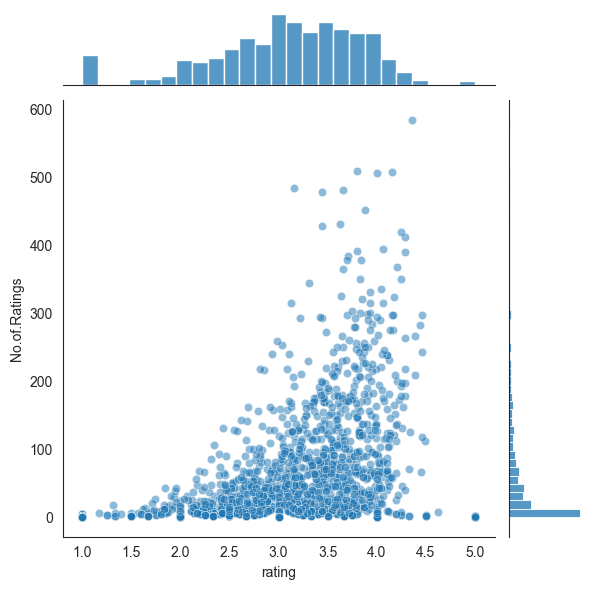

In [31]:
sns.jointplot(x= 'rating',y = 'No.of.Ratings',data= ratings,alpha=0.5)

## Recommended Similar Movies 
##### Now let's create a matrix that has the user ids on one access and the movies title on another axis Each cell will then consist of the rating the user gave to that movie Note there will be a lot of Nan values Because most people have  not seen mose of the movies

In [32]:
moviemat = df.pivot_table(index= 'user_id',columns= 'title',values='rating')
moviemat.head()

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
ratings.sort_values('No.of.Ratings', ascending = False).head(15)

,rating,No.of.Ratings
title,,
Star Wars (1977),4.359589,584
Contact (1997),3.803536,509
Fargo (1996),4.155512,508
Return of the Jedi (1983),4.007890,507
Liar Liar (1997),3.156701,485
"English Patient, The (1996)",3.656965,481
Scream (1996),3.441423,478
Toy Story (1995),3.878319,452
Air Force One (1997),3.631090,431


In [34]:
ratings.head()

,rating,No.of.Ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


In [35]:
starwar = moviemat['Star Wars (1977)']
liar = moviemat['Liar Liar (1997)']
starwar.head()

user_id
0    5.0
1    5.0
2    5.0
3    NaN
4    5.0
Name: Star Wars (1977), dtype: float64

In [36]:
similar_to_starwars = moviemat.corrwith(starwar)
similar_to_liar = moviemat.corrwith(liar)

C:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
C:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
C:\Users\MANIKANDAN\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


### Lets clean this by removing NaN values and using a DataFrame instead of a Series

In [43]:
corr_starwars= pd.DataFrame(similar_to_starwars,columns=['Correlation'])
corr_starwars.dropna(inplace= True)
corr_starwars.head()

,Correlation
title,
'Til There Was You (1997),0.872872
1-900 (1994),-0.645497
101 Dalmatians (1996),0.211132
12 Angry Men (1957),0.184289
187 (1997),0.027398


#### Now it we sort the dataframe by correlation we should get the most similar movies however note that we get some results that don't really make sense this is because there are a lot of movies only watched once by users who also  watched star wars(it was the most popular movie)

In [47]:
corr_starwars.sort_values('Correlation',ascending= False).head(10)

,Correlation
title,
Star Wars (1977),1.0
Stripes (1981),1.0
Hollow Reed (1996),1.0
Man of the Year (1995),1.0
Cosi (1996),1.0
Commandments (1997),1.0
No Escape (1994),1.0
"Scarlet Letter, The (1926)",1.0
Safe Passage (1994),1.0


##### Let's fix this by filtering out movies that have less than 100 reviews (this value was chosen based off the histogram from earlier)

In [49]:
corr_starwars['num of ratings'] =  pd.DataFrame(ratings.groupby('title')['rating']).count()
corr_starwars.head()

,Correlation,num of ratings
title,,
'Til There Was You (1997),0.872872,NaN
1-900 (1994),-0.645497,NaN
101 Dalmatians (1996),0.211132,NaN
12 Angry Men (1957),0.184289,NaN
187 (1997),0.027398,NaN


In [51]:
corr_starwars[corr_starwars['num of ratings'] > 100].sort_values('Correlation',ascending = False).head() 

,Correlation,num of ratings
title,,


In [53]:
corr_liar = pd.DataFrame(similar_to_liar, columns =['Correlation'])
corr_liar.head()

,Correlation
title,
'Til There Was You (1997),0.118913
1-900 (1994),NaN
101 Dalmatians (1996),0.469765
12 Angry Men (1957),0.066272
187 (1997),0.175145


In [54]:
corr_liar.dropna(inplace = True)
corr_liar.head()

,Correlation
title,
'Til There Was You (1997),0.118913
101 Dalmatians (1996),0.469765
12 Angry Men (1957),0.066272
187 (1997),0.175145
2 Days in the Valley (1996),0.040739


In [55]:
corr_liar = corr_liar.join(ratings['No.of.Ratings'])
corr_liar.head()

,Correlation,No.of.Ratings
title,,
'Til There Was You (1997),0.118913,9
101 Dalmatians (1996),0.469765,109
12 Angry Men (1957),0.066272,125
187 (1997),0.175145,41
2 Days in the Valley (1996),0.040739,93


In [56]:
corr_liar[corr_liar['No.of.Ratings'] > 100].sort_values('Correlation',ascending = False).head()

,Correlation,No.of.Ratings
title,,
Liar Liar (1997),1.000000,485
Batman Forever (1995),0.516968,114
"Mask, The (1994)",0.484650,129
Down Periscope (1996),0.472681,101
Con Air (1997),0.469828,137
